In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings

sns.set_theme(style='whitegrid')

In [ ]:
df_stations = pd.read_csv('Station_Details_Historical.csv')
df_pollutants = pd.read_csv('Pollutant_Historical.csv')
df_aqi = pd.read_csv('AQI_Category_Historical.csv')
df_climate = pd.read_csv('Climate_Conditions_Historical.csv')

df_aqi

,Station_id,timestamp,Exact_AQI,category_name,Range,Health_advisory
0,ST-AR-001,2026-02-01 00:00:00,59,Satisfactory,51-100,Minor breathing discomfort to sensitive people
1,ST-AR-001,2026-02-01 01:00:00,59,Satisfactory,51-100,Minor breathing discomfort to sensitive people
2,ST-AR-001,2026-02-01 02:00:00,59,Satisfactory,51-100,Minor breathing discomfort to sensitive people
3,ST-AR-001,2026-02-01 03:00:00,59,Satisfactory,51-100,Minor breathing discomfort to sensitive people
4,ST-AR-001,2026-02-01 04:00:00,59,Satisfactory,51-100,Minor breathing discomfort to sensitive people
...,...,...,...,...,...,...
88027,ST-TR-131,2026-02-28 19:00:00,172,Moderate,101-200,"Breathing discomfort to people with lung, asth..."
88028,ST-TR-131,2026-02-28 20:00:00,161,Moderate,101-200,"Breathing discomfort to people with lung, asth..."
88029,ST-TR-131,2026-02-28 21:00:00,161,Moderate,101-200,"Breathing discomfort to people with lung, asth..."
88030,ST-TR-131,2026-02-28 22:00:00,161,Moderate,101-200,"Breathing discomfort to people with lung, asth..."


In [ ]:
df_merged = df_pollutants.merge(df_aqi, on=['Station_id', 'timestamp'], how='inner')
df_merged = df_merged.merge(df_climate, on=['Station_id', 'timestamp'], how='inner')
df_merged = df_merged.merge(df_stations[['Station_id', 'City']], on='Station_id', how='inner')
df_merged['timestamp'] = pd.to_datetime(df_merged['timestamp'])

def extract_wind(val):
    try:
        return float(str(val).split(' ')[0])
    except:
        return np.nan
        
df_merged['wind_speed_kmh'] = df_merged['wind_speed_and_direction'].apply(extract_wind)

print(f'combined dataset shape: {df_merged.shape}')
df_merged.head(3)

combined dataset shape: (88032, 16)


,Station_id,timestamp,PM2_5,PM10,CO,NO2,Exact_AQI,category_name,Range,Health_advisory,wind_speed_and_direction,temperature,precipitation,relative_humidity,City,wind_speed_kmh
0,ST-AR-001,2026-02-01 00:00:00,15.8,17.6,203.0,11.9,59,Satisfactory,51-100,Minor breathing discomfort to sensitive people,"3.2 km/h, 317 deg",-11.1,0.0,95,Anjaw,3.2
1,ST-AR-001,2026-02-01 01:00:00,14.2,15.7,207.0,10.3,59,Satisfactory,51-100,Minor breathing discomfort to sensitive people,"3.4 km/h, 317 deg",-11.4,0.0,95,Anjaw,3.4
2,ST-AR-001,2026-02-01 02:00:00,12.9,14.2,212.0,9.0,59,Satisfactory,51-100,Minor breathing discomfort to sensitive people,"3.3 km/h, 319 deg",-11.2,0.0,94,Anjaw,3.3


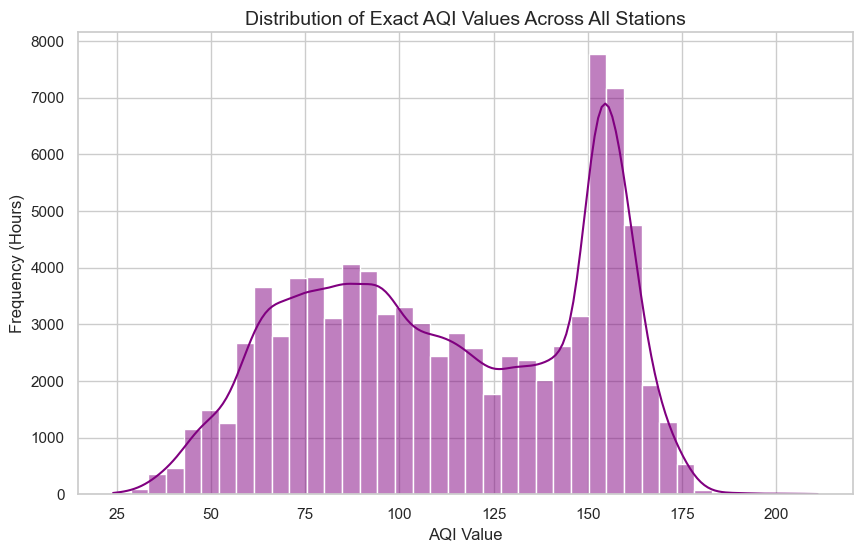

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df_merged['Exact_AQI'].dropna(), bins=40, kde=True, color='purple')
plt.title('Distribution of Exact AQI Values Across All Stations', fontsize=14)
plt.xlabel('AQI Value')
plt.ylabel('Frequency (Hours)')
plt.show()

In [ ]:
sns.kdeplot(df_merged['Exact_AQI'],color = 'pink',fill=True)

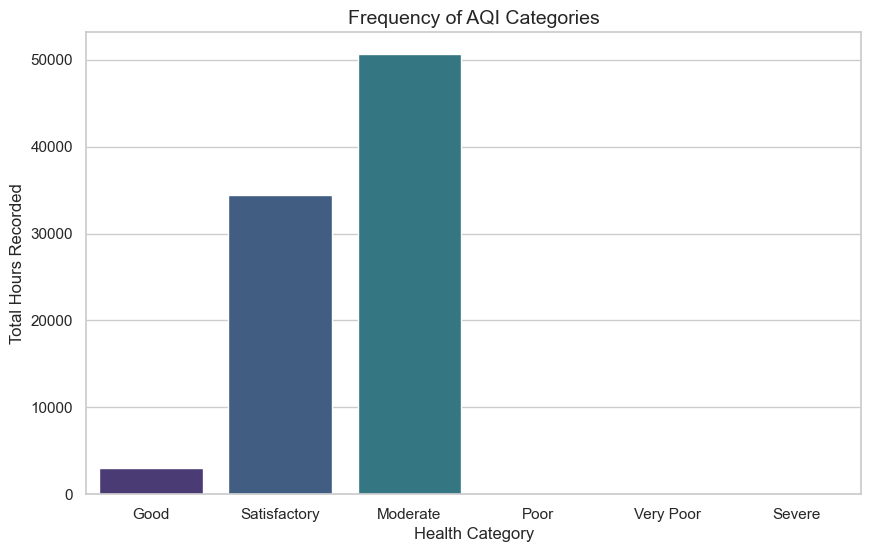

In [7]:
plt.figure(figsize=(10, 6))
category_order = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
sns.countplot(data=df_merged, x='category_name', order=category_order, palette='viridis')
plt.title('Frequency of AQI Categories', fontsize=14)
plt.xlabel('Health Category')
plt.ylabel('Total Hours Recorded')
plt.show()

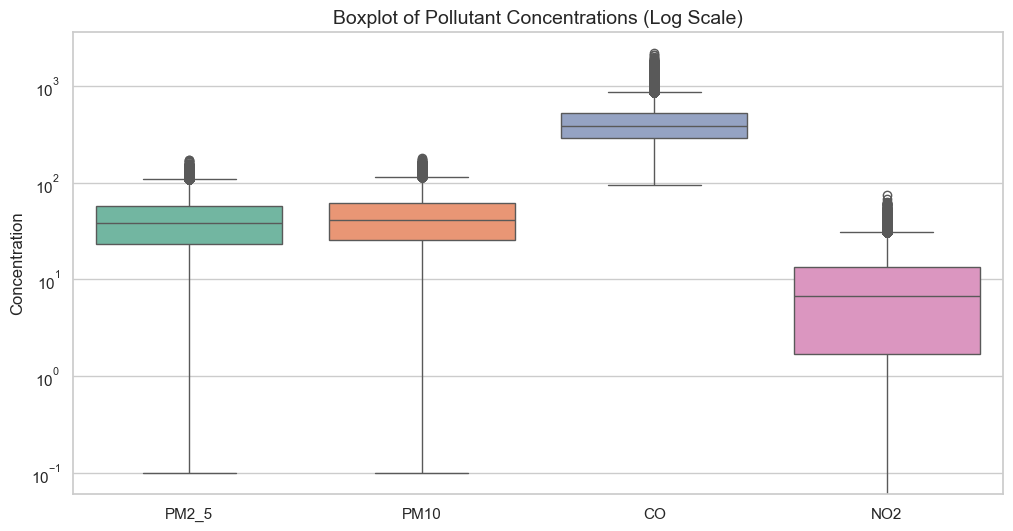

In [10]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_merged[['PM2_5', 'PM10', 'CO', 'NO2']], palette='Set2')
plt.title('Boxplot of Pollutant Concentrations (Log Scale)', fontsize=14)
plt.ylabel('Concentration')
plt.yscale('log')
plt.show()

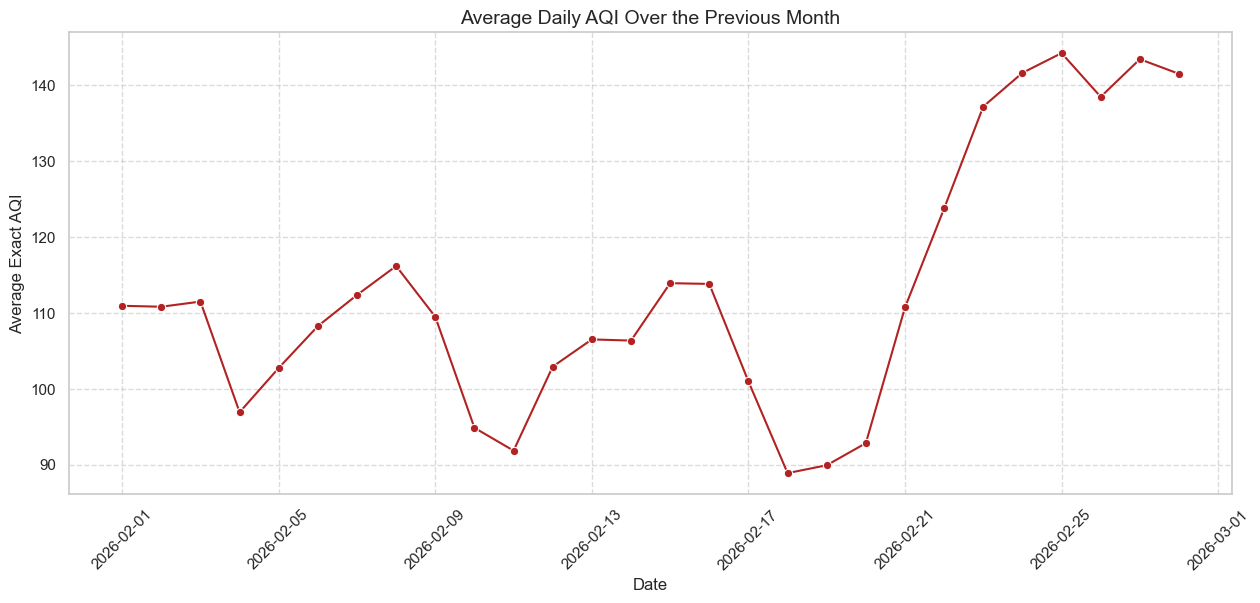

In [11]:
plt.figure(figsize=(15, 6))
daily_aqi = df_merged.groupby(df_merged['timestamp'].dt.date)['Exact_AQI'].mean()
sns.lineplot(x=daily_aqi.index, y=daily_aqi.values, marker='o', color='firebrick')
plt.title('Average Daily AQI Over the Previous Month', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Average Exact AQI')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

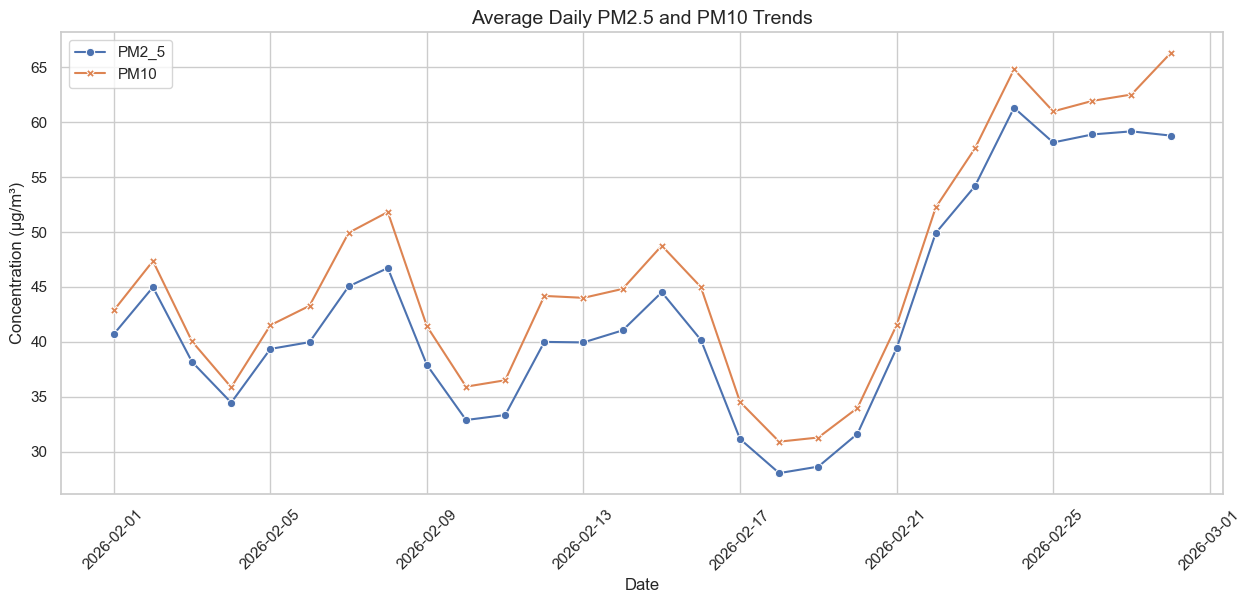

In [12]:
plt.figure(figsize=(15, 6))
daily_pollutants = df_merged.groupby(df_merged['timestamp'].dt.date)[['PM2_5', 'PM10']].mean()
sns.lineplot(data=daily_pollutants, markers=True, dashes=False)
plt.title('Average Daily PM2.5 and PM10 Trends', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Concentration (μg/m³)')
plt.xticks(rotation=45)
plt.show()

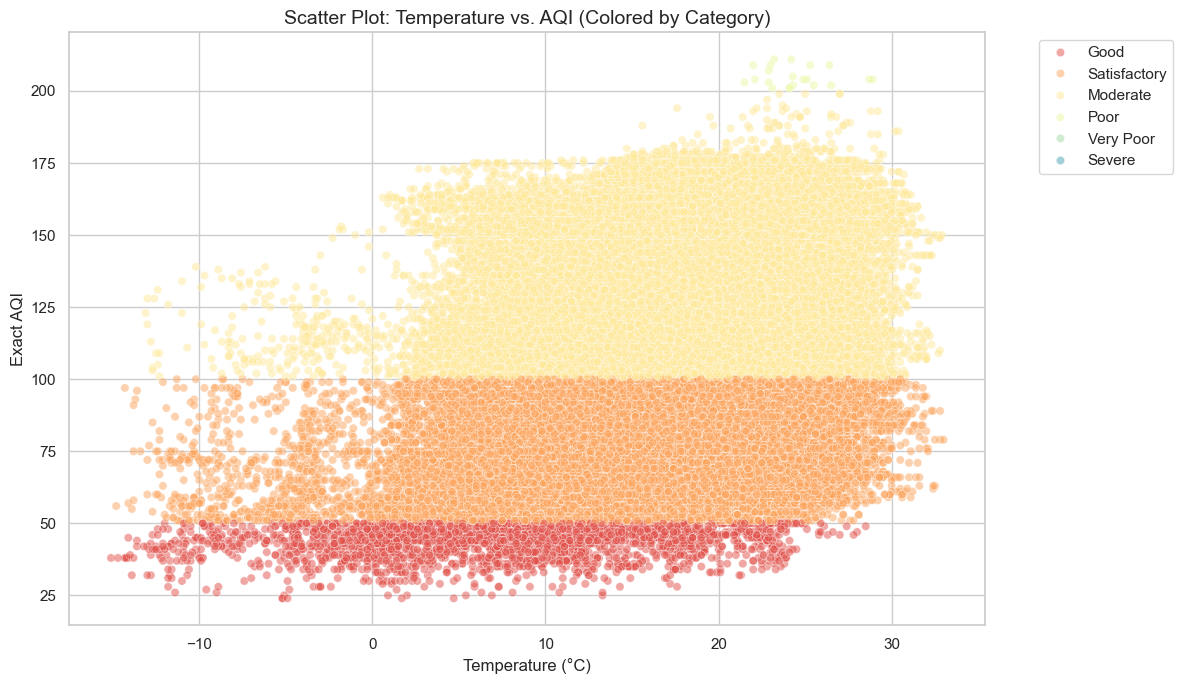

In [13]:
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df_merged, 
    x='temperature', 
    y='Exact_AQI', 
    alpha=0.5, 
    hue='category_name', 
    palette='Spectral', 
    hue_order=category_order
)
plt.title('Scatter Plot: Temperature vs. AQI (Colored by Category)', fontsize=14)
plt.xlabel('Temperature (°C)')
plt.ylabel('Exact AQI')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

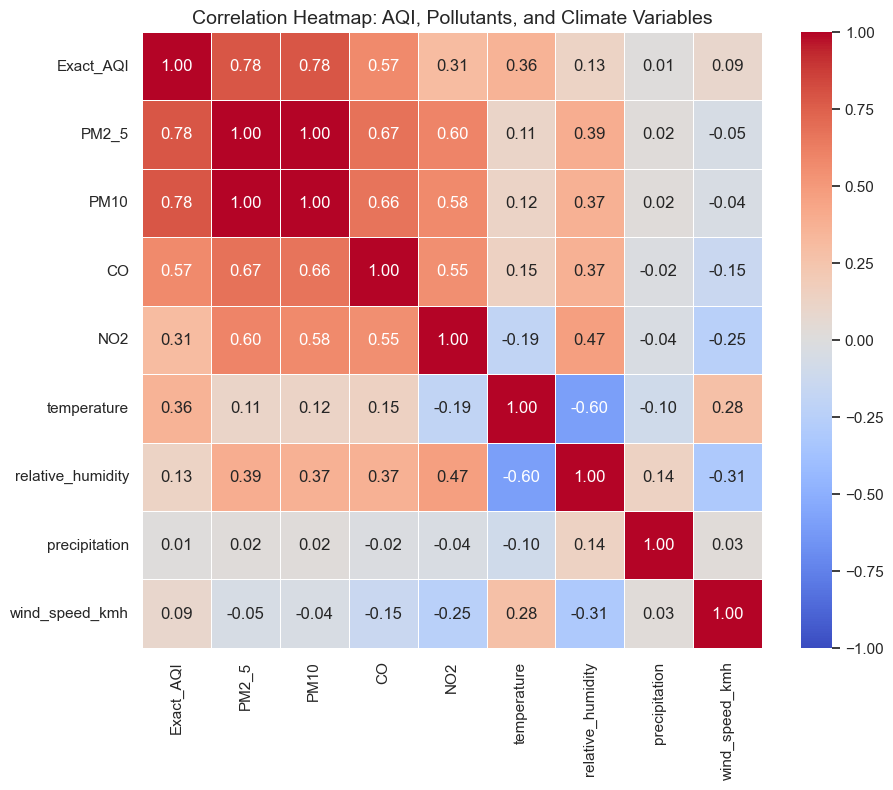

In [14]:
plt.figure(figsize=(10, 8))
corr_cols = ['Exact_AQI', 'PM2_5', 'PM10', 'CO', 'NO2', 'temperature', 'relative_humidity', 'precipitation', 'wind_speed_kmh']
corr_matrix = df_merged[corr_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap: AQI, Pollutants, and Climate Variables', fontsize=14)
plt.show()

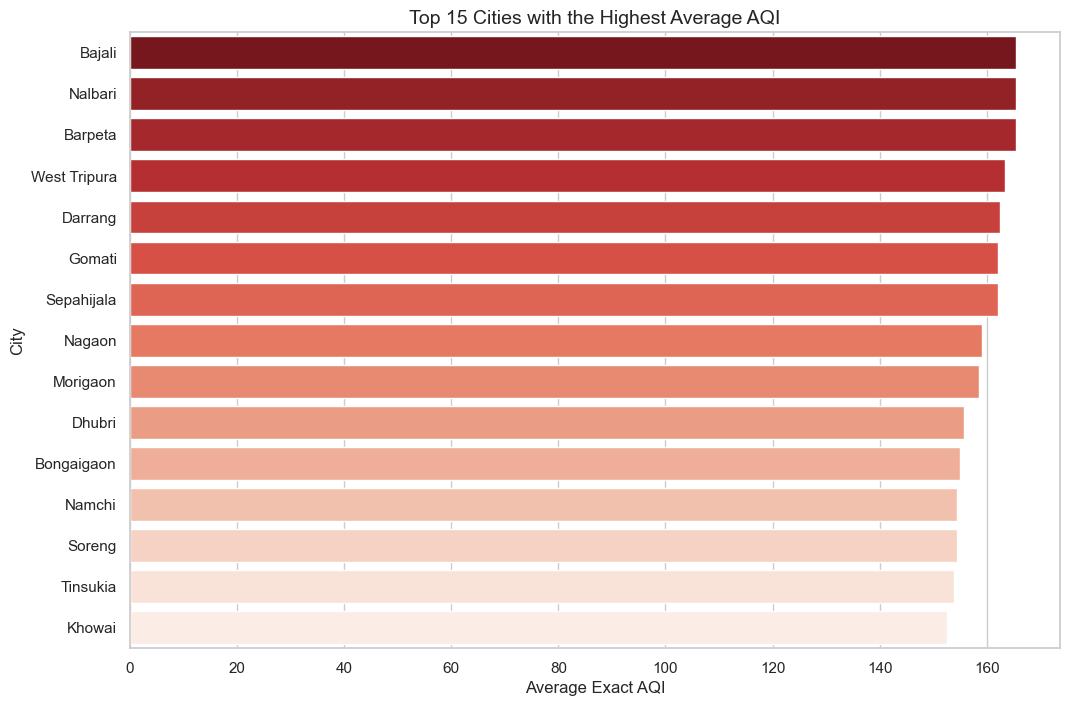

In [15]:
plt.figure(figsize=(12, 8))
top_cities = df_merged.groupby('City')['Exact_AQI'].mean().sort_values(ascending=False).head(15)

sns.barplot(x=top_cities.values, y=top_cities.index, palette='Reds_r')
plt.title('Top 15 Cities with the Highest Average AQI', fontsize=14)
plt.xlabel('Average Exact AQI')
plt.ylabel('City')
plt.show()

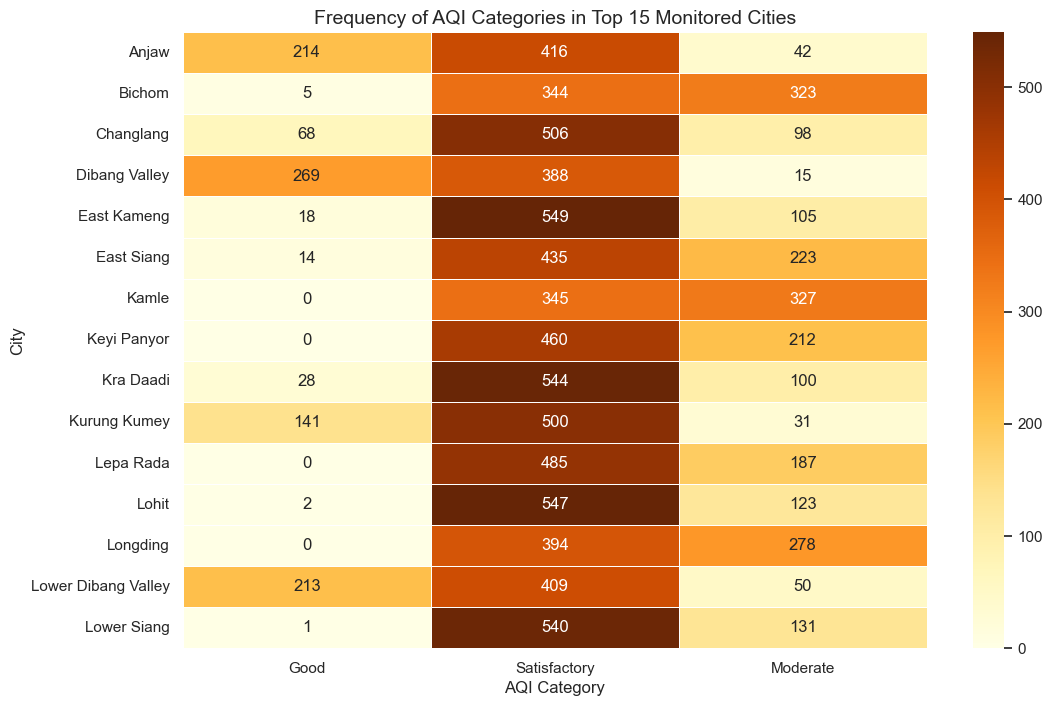

In [16]:
plt.figure(figsize=(12, 8))
top_15_cities = df_merged['City'].value_counts().head(15).index
city_cat_data = df_merged[df_merged['City'].isin(top_15_cities)]

pivot_data = city_cat_data.groupby(['City', 'category_name']).size().unstack().fillna(0)

cols = [c for c in category_order if c in pivot_data.columns]
pivot_data = pivot_data[cols]

sns.heatmap(pivot_data, cmap='YlOrBr', annot=True, fmt='g', linewidths=.5)
plt.title('Frequency of AQI Categories in Top 15 Monitored Cities', fontsize=14)
plt.xlabel('AQI Category')
plt.ylabel('City')
plt.show()